## NVDA Time Series – Main Notebook

This notebook replaces the previous `main.py` script as the primary interactive entry point for the NVDA projects.

Use it to:
- Download and load the NVDA dataset.
- Run preprocessing and basic data description.
- Inspect the DataFrame with commands like `df.head()`.
- Later: perform transformations to returns and add visualizations (after we verify the time-series structure).


In [1]:
from data_loader import download_nvda_data, load_nvda_data
from preprocessing import preprocess_prices
from analysis import print_data_overview, print_descriptive_statistics

df = None  # will hold the processed NVDA DataFrame


In [2]:
# Step 1: download (or refresh) the NVDA dataset and save it as CSV.
download_nvda_data()

# Step 2: load the saved dataset from disk and preprocess prices.
df = load_nvda_data()
df = preprocess_prices(df)

print_data_overview(df)
print_descriptive_statistics(
    df,
    columns=["Open", "High", "Low", "Close", "Volume"],
    title="Price and volume descriptive statistics",
)


[*********************100%***********************]  1 of 1 completed

Downloaded 1297 rows for NVDA and saved to C:\Users\ass\Documents\NVDA\data\nvda_raw.csv
=== Data overview ===
Number of rows: 1297
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']
Date range: 2021-01-04 00:00:00 -> 2026-03-04 00:00:00

=== Price and volume descriptive statistics ===
              Open         High          Low        Close        Volume
count  1297.000000  1297.000000  1297.000000  1297.000000  1.297000e+03
mean     71.062795    72.241455    69.736683    71.038813  3.879523e+08
std      60.419920    61.230511    59.402573    60.325123  1.846455e+08
min      10.957224    11.720265    10.799422    11.212903  6.552850e+07
25%      19.641072    19.984306    19.207045    19.618124  2.313979e+08
50%      42.720443    43.583291    42.103367    42.965748  3.713890e+08
75%     123.746155   126.445877   120.978210   123.997536  5.011480e+08
max     208.068415   212.178195   205.548551   207.028473  1.543911e+09



In [3]:
# Inspect the first few rows to understand the structure.
df.head(15)


,Close,High,Low,Open,Volume
Date,,,,,
2021-01-04,13.076726,13.614215,12.926149,13.067502,560640000
2021-01-05,13.367161,13.405802,13.050302,13.063016,322760000
2021-01-06,12.579125,13.207857,12.550706,13.185420,580424000
2021-01-07,13.306579,13.340235,12.850362,12.931134,461480000
2021-01-08,13.239517,13.383363,13.005426,13.325027,292528000
2021-01-11,13.583302,13.921850,13.325028,13.381120,518344000
2021-01-12,13.446935,13.715929,13.307577,13.713934,291476000
2021-01-13,13.493802,13.586791,13.347464,13.452169,210028000
2021-01-14,13.163234,13.561613,13.143539,13.536933,283120000


In [4]:
from preprocessing import add_return_columns

# Transform Close prices into simple and log returns
# (Run this after the previous cells so that `df` is defined.)

df = add_return_columns(df, price_column="Close")

print_descriptive_statistics(
    df,
    columns=["Return_simple", "Return_log"],
    title="Return descriptive statistics",
)

df[["Close", "Return_simple", "Return_log"]].head()

=== Return descriptive statistics ===
       Return_simple   Return_log
count    1296.000000  1296.000000
mean        0.002565     0.002036
std         0.032633     0.032384
min        -0.169682    -0.185946
25%        -0.015890    -0.016018
50%         0.002904     0.002900
75%         0.020797     0.020584
max         0.243696     0.218088



,Close,Return_simple,Return_log
Date,,,
2021-01-04,13.076726,NaN,NaN
2021-01-05,13.367161,0.022210,0.021967
2021-01-06,12.579125,-0.058953,-0.060762
2021-01-07,13.306579,0.057830,0.056220
2021-01-08,13.239517,-0.005040,-0.005052


In [5]:
from analysis import extended_descriptive_table

# Extended statistics for prices and returns (mean, variance, std, range, IQR, skewness, kurtosis)
extended_descriptive_table(
    df,
    columns=["Close", "Return_simple", "Return_log"],
    title="Extended statistics for prices and returns",
)

=== Extended statistics for prices and returns ===
                       Close  Return_simple  Return_log
mean               71.038813       0.002565    0.002036
variance         3639.120497       0.001065    0.001049
std                60.325123       0.032633    0.032384
min                11.212903      -0.169682   -0.185946
max               207.028473       0.243696    0.218088
range             195.815570       0.413378    0.404034
Q1                 19.618124      -0.015890   -0.016018
median             42.965748       0.002904    0.002900
Q3                123.997536       0.020797    0.020584
IQR               104.379412       0.036687    0.036602
skewness            0.716438       0.512090    0.228584
kurtosis            2.008819       7.521640    6.677599
excess_kurtosis    -0.991181       4.521640    3.677599



,Close,Return_simple,Return_log
mean,71.038813,0.002565,0.002036
variance,3639.120497,0.001065,0.001049
std,60.325123,0.032633,0.032384
min,11.212903,-0.169682,-0.185946
max,207.028473,0.243696,0.218088
range,195.815570,0.413378,0.404034
Q1,19.618124,-0.015890,-0.016018
median,42.965748,0.002904,0.002900
Q3,123.997536,0.020797,0.020584
IQR,104.379412,0.036687,0.036602


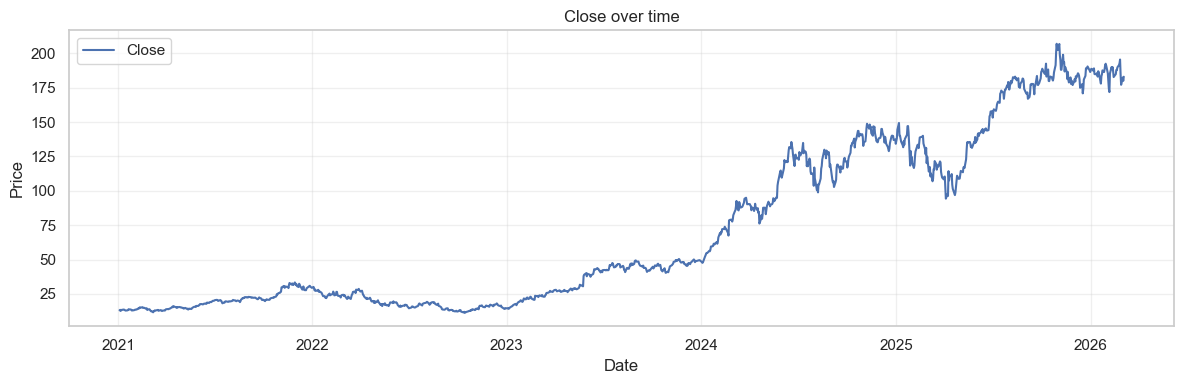

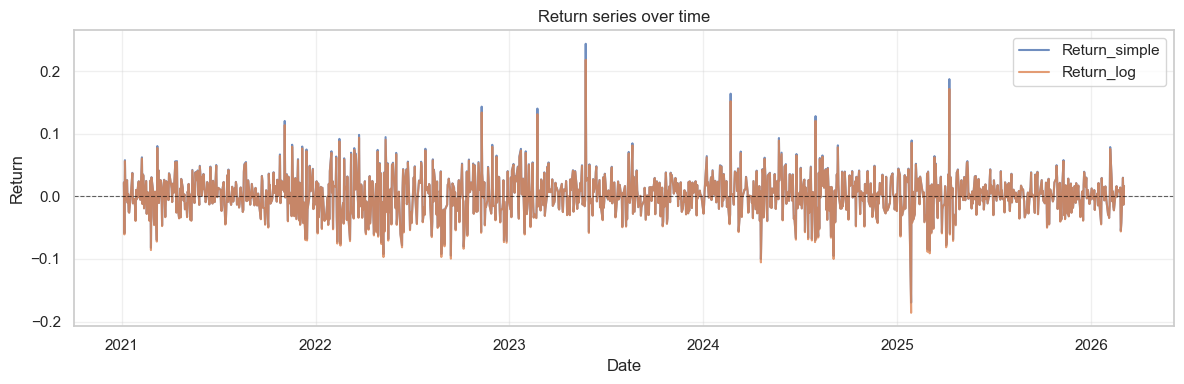

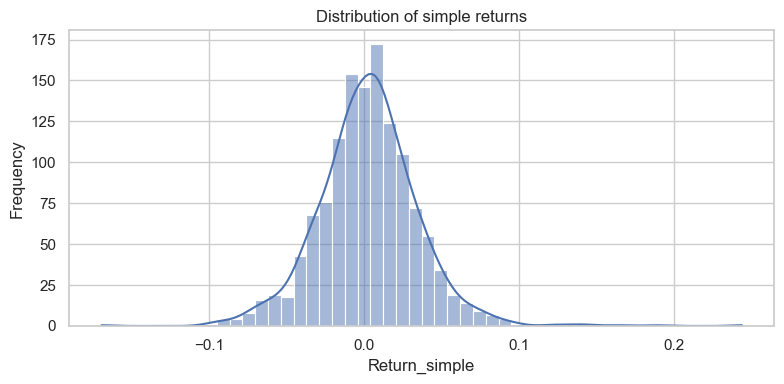

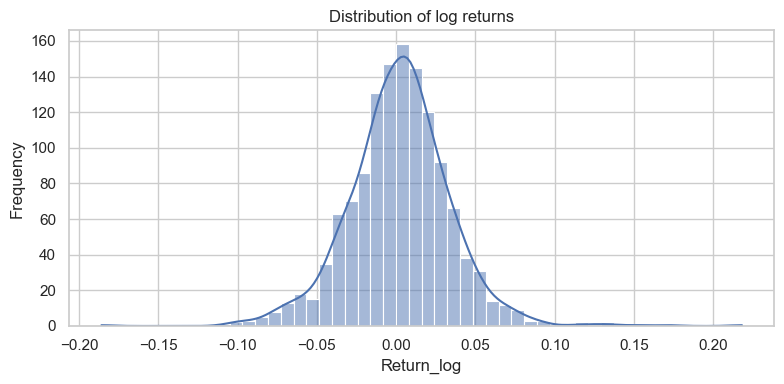

In [7]:
import matplotlib.pyplot as plt  # pyright: ignore[reportMissingImports]
import seaborn as sns  # pyright: ignore[reportMissingModuleSource]
from analysis import plot_price_series, plot_return_series, plot_distribution

sns.set(style="whitegrid")

# Time series plots
plot_price_series(df, price_column="Close")
plot_return_series(df, columns=["Return_simple", "Return_log"])

# Distribution plots for returns
plot_distribution(df, column="Return_simple", title="Distribution of simple returns")
plot_distribution(df, column="Return_log", title="Distribution of log returns")

In [9]:
import pandas as pd
import numpy as np

# ── Volume summary table ────────────────────────────────────────────────────
vol = df["Volume"]

stats = {
    "Count":           vol.count(),
    "Mean":            vol.mean(),
    "Std Dev":         vol.std(),
    "Min":             vol.min(),
    "5th Pct":         vol.quantile(0.05),
    "25th Pct":        vol.quantile(0.25),
    "Median":          vol.median(),
    "75th Pct":        vol.quantile(0.75),
    "95th Pct":        vol.quantile(0.95),
    "Max":             vol.max(),
    "IQR":             vol.quantile(0.75) - vol.quantile(0.25),
    "Skewness":        vol.skew(),
    "Excess Kurtosis": vol.kurtosis(),
}

vol_table = pd.DataFrame.from_dict(stats, orient="index", columns=["Volume"])
vol_table.index.name = "Statistic"

# Format large numbers for readability
def fmt(x):
    if abs(x) >= 1e6:
        return f"{x/1e6:,.2f} M"
    elif abs(x) >= 1:
        return f"{x:,.0f}"
    else:
        return f"{x:.4f}"

vol_table_fmt = vol_table.copy()
vol_table_fmt["Volume"] = vol_table["Volume"].apply(fmt)

print("\n=== NVDA – Volume Descriptive Statistics ===")
print(vol_table_fmt.to_string())

# Top-10 highest-volume trading days
top10 = df[["Close", "Volume"]].nlargest(10, "Volume").copy()
top10["Volume (M)"] = (top10["Volume"] / 1e6).round(2)
top10["Return (%)"] = (df["Return_simple"] * 100).round(2)
print("\n=== Top-10 Highest-Volume Days ===")
print(top10[["Close", "Volume (M)", "Return (%)"]].to_string())



=== NVDA – Volume Descriptive Statistics ===
                     Volume
Statistic                  
Count                 1,297
Mean               387.95 M
Std Dev            184.65 M
Min                 65.53 M
5th Pct            153.14 M
25th Pct           231.40 M
Median             371.39 M
75th Pct           501.15 M
95th Pct           705.34 M
Max              1,543.91 M
IQR                269.75 M
Skewness             0.9316
Excess Kurtosis           2

=== Top-10 Highest-Volume Days ===
                Close  Volume (M)  Return (%)
Date                                         
2023-05-25  37.948460     1543.91       24.37
2022-09-01  13.915365     1178.86       -7.67
2023-08-24  47.128708     1156.04        0.10
2021-11-04  29.739742     1153.63       12.04
2024-03-08  87.483376     1142.27       -5.55
2023-02-23  23.640333     1117.99       14.02
2023-05-31  37.802582     1002.58       -5.68
2022-05-26  17.819519      996.58        5.16
2022-08-08  17.765379      981.86     

### 2.4 Visual Descriptive Analysis – Volume

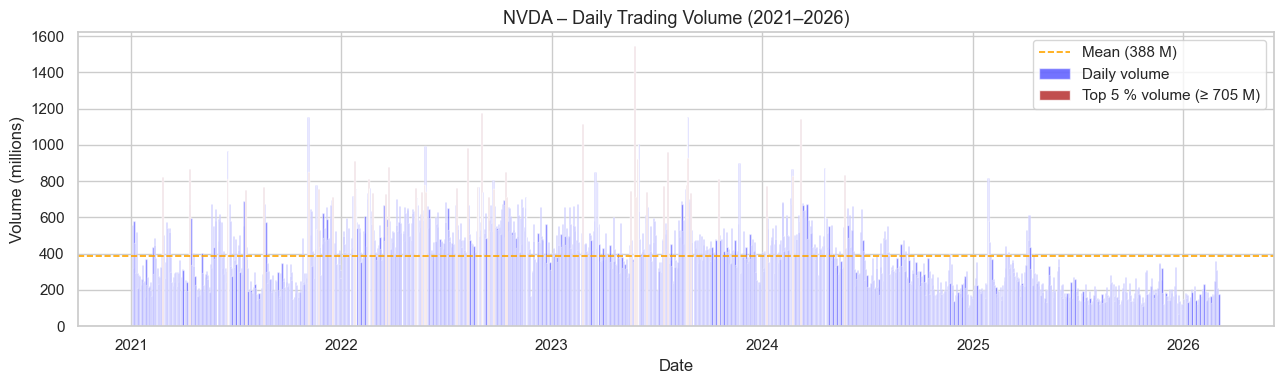

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

threshold_95 = df["Volume"].quantile(0.95)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(df.index, df["Volume"] / 1e6,
       color="blue", alpha=0.55, width=2, label="Daily volume")

# Highlight top-5 % volume days in red
extreme = df[df["Volume"] >= threshold_95]
ax.bar(extreme.index, extreme["Volume"] / 1e6,
       color="firebrick", alpha=0.80, width=1,
       label=f"Top 5 % volume (≥ {threshold_95/1e6:.0f} M)")

ax.axhline(df["Volume"].mean() / 1e6, color="orange", linewidth=1.2,
           linestyle="--", label=f"Mean ({df['Volume'].mean()/1e6:.0f} M)")

ax.set_title("NVDA – Daily Trading Volume (2021–2026)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Volume (millions)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()


### 2.5 Boxplots of Returns

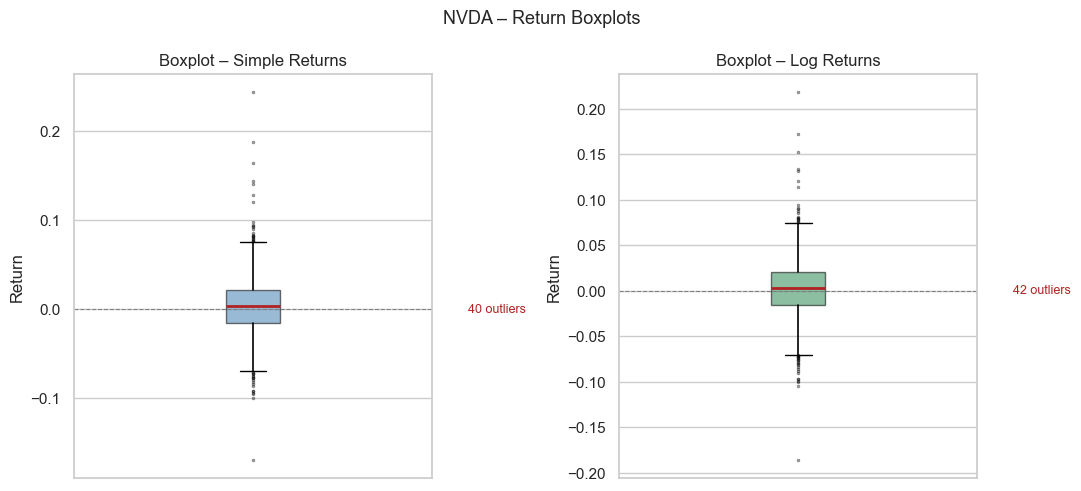

In [19]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
palette = {"Return_simple": "steelblue", "Return_log": "seagreen"}

for ax, col, label, color in zip(
    axes,
    ["Return_simple", "Return_log"],
    ["Simple Returns", "Log Returns"],
    ["steelblue", "seagreen"]
):
    data = df[col].dropna()
    ax.boxplot(
        data,
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.55),
        medianprops=dict(color="firebrick", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        flierprops=dict(marker=".", markersize=3, alpha=0.45, color=color),
    )
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"Boxplot – {label}")
    ax.set_ylabel("Return")
    ax.set_xticks([])

    # Annotate outlier count
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    ax.text(1.1, 0, f"{n_out} outliers", transform=ax.get_yaxis_transform(),
            fontsize=9, color="firebrick", va="center")

plt.suptitle("NVDA – Return Boxplots", fontsize=13)
plt.tight_layout()
plt.show()


### 2.6 Interpretation – Capital Markets Focus

**Price level and volatility**  
NVDA traded between roughly \$11 and \$207 over the sample, with a mean close of ~\$71 and a standard deviation of ~\$60 — a coefficient of variation above 80 %, indicating very wide dispersion relative to the mean. This is consistent with a high-growth, momentum-driven equity.

**Trends, crashes, and regime changes**  
Three distinct regimes are visible in the price series:
1. **2021 – early 2022**: Steady AI-driven rally from ~\$15 to ~\$35 (split-adjusted).
2. **2022**: Sharp drawdown (~65 %) as rate hikes repriced growth stocks broadly.
3. **2023 – 2026**: Explosive recovery and new highs driven by generative-AI compute demand, with the price exceeding \$150 by late 2024.

**Return characteristics**  
Daily simple returns average +0.26 % (≈ +90 % annualised) with a 3.26 % daily standard deviation (≈ 52 % annualised volatility). Excess kurtosis of 4.5 confirms **fat tails** — extreme daily moves occur far more often than a Gaussian model predicts. The slight positive skew reflects more large upside days than large downside days over the sample.

**Volume and market events**  
Average daily volume is moderate, but the top-5 % of days (highlighted in red) cluster around earnings releases, major AI announcements (e.g., ChatGPT launch, GTC conferences), and the 2022 sell-off. High volume on large-move days confirms institutional participation rather than thin-market noise. The volume distribution is strongly right-skewed (skewness > 2), meaning a handful of event-driven days account for a disproportionate share of turnover.


---
## Section 3 – Time Series Analysis
### 3.1 Stationarity Diagnostics – Augmented Dickey-Fuller Test

In [22]:
from statsmodels.tsa.stattools import adfuller  # pyright: ignore[reportMissingImports]
import pandas as pd

def run_adf(series, label):
    """Run ADF test and print a formatted summary."""
    clean = series.dropna()
    res = adfuller(clean, autolag="AIC")
    sig = res[1] < 0.05
    rows = [
        ("Test statistic",    f"{res[0]:.4f}"),
        ("p-value",           f"{res[1]:.4f}"),
        ("Lags used",         str(res[2])),
        ("Obs. used",         str(res[3])),
        ("CV 1 %",            f"{res[4]['1%']:.4f}"),
        ("CV 5 %",            f"{res[4]['5%']:.4f}"),
        ("CV 10 %",           f"{res[4]['10%']:.4f}"),
        ("Conclusion",        "STATIONARY (reject H₀)" if sig else "NON-STATIONARY (fail to reject H₀)"),
    ]
    tbl = pd.DataFrame(rows, columns=["Metric", label]).set_index("Metric")
    return tbl

tbl_price   = run_adf(df["Close"],         "Close")
tbl_simple  = run_adf(df["Return_simple"],  "Return_simple")
tbl_log     = run_adf(df["Return_log"],     "Return_log")

result_table = pd.concat([tbl_price, tbl_simple, tbl_log], axis=1)
print("=== Augmented Dickey-Fuller Unit-Root Tests ===")
print(result_table.to_string())
print("\nInterpretation: Prices are expected to be non-stationary (unit root);")
print("returns should be stationary – confirmed by ADF p < 0.05.")


=== Augmented Dickey-Fuller Unit-Root Tests ===
                                             Close           Return_simple              Return_log
Metric                                                                                            
Test statistic                              0.5142                -21.9544                -37.6194
p-value                                     0.9853                  0.0000                  0.0000
Lags used                                       15                       2                       0
Obs. used                                     1281                    1293                    1295
CV 1 %                                     -3.4355                 -3.4354                 -3.4354
CV 5 %                                     -2.8638                 -2.8638                 -2.8638
CV 10 %                                    -2.5680                 -2.5680                 -2.5680
Conclusion      NON-STATIONARY (fail to reject H₀)  STATIONAR

### 3.2 Autocorrelation Analysis – Returns

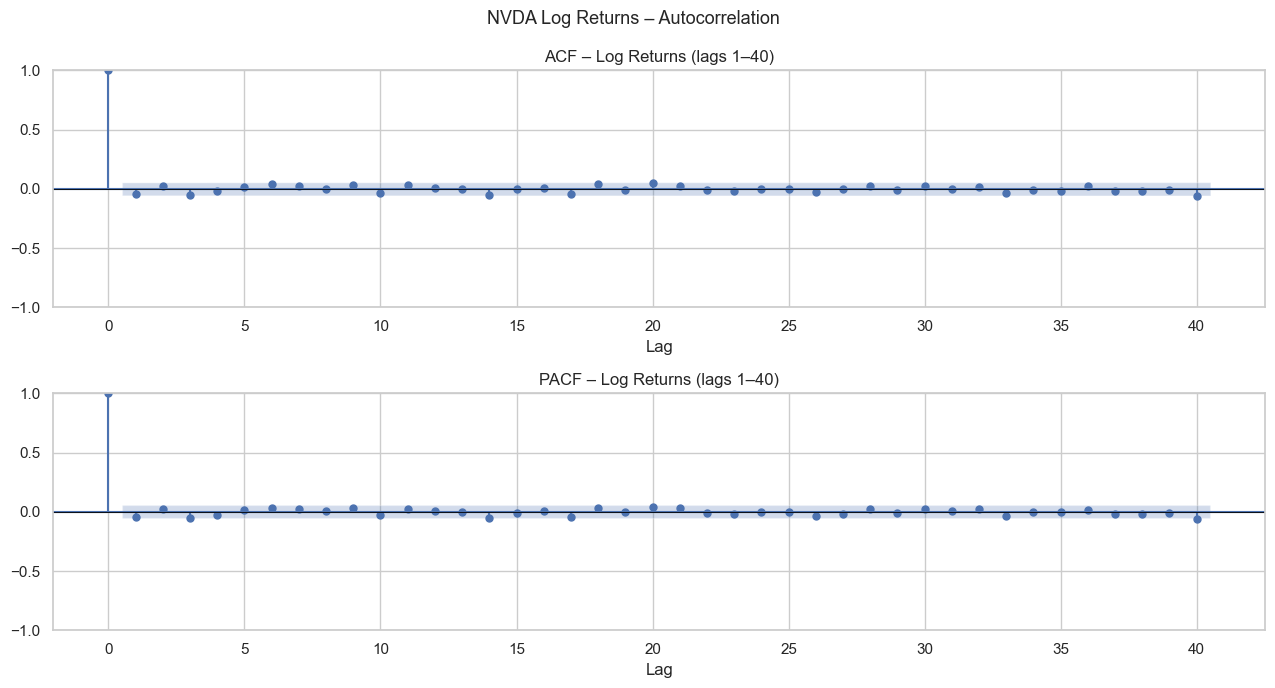

Interpretation: If all ACF/PACF bars stay within the 95 % confidence bands,
returns are serially uncorrelated → consistent with weak-form efficiency.


In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # pyright: ignore
import matplotlib.pyplot as plt

returns = df["Return_log"].dropna()

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
plot_acf(returns,  lags=40, ax=axes[0], alpha=0.05,
         title="ACF – Log Returns (lags 1–40)")
plot_pacf(returns, lags=40, ax=axes[1], alpha=0.05,
          method="ywm", title="PACF – Log Returns (lags 1–40)")
for ax in axes:
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_xlabel("Lag")
plt.suptitle("NVDA Log Returns – Autocorrelation", fontsize=13)
plt.tight_layout()
plt.show()
print("Interpretation: If all ACF/PACF bars stay within the 95 % confidence bands,")
print("returns are serially uncorrelated → consistent with weak-form efficiency.")


### 3.3 Volatility Clustering – Squared Returns

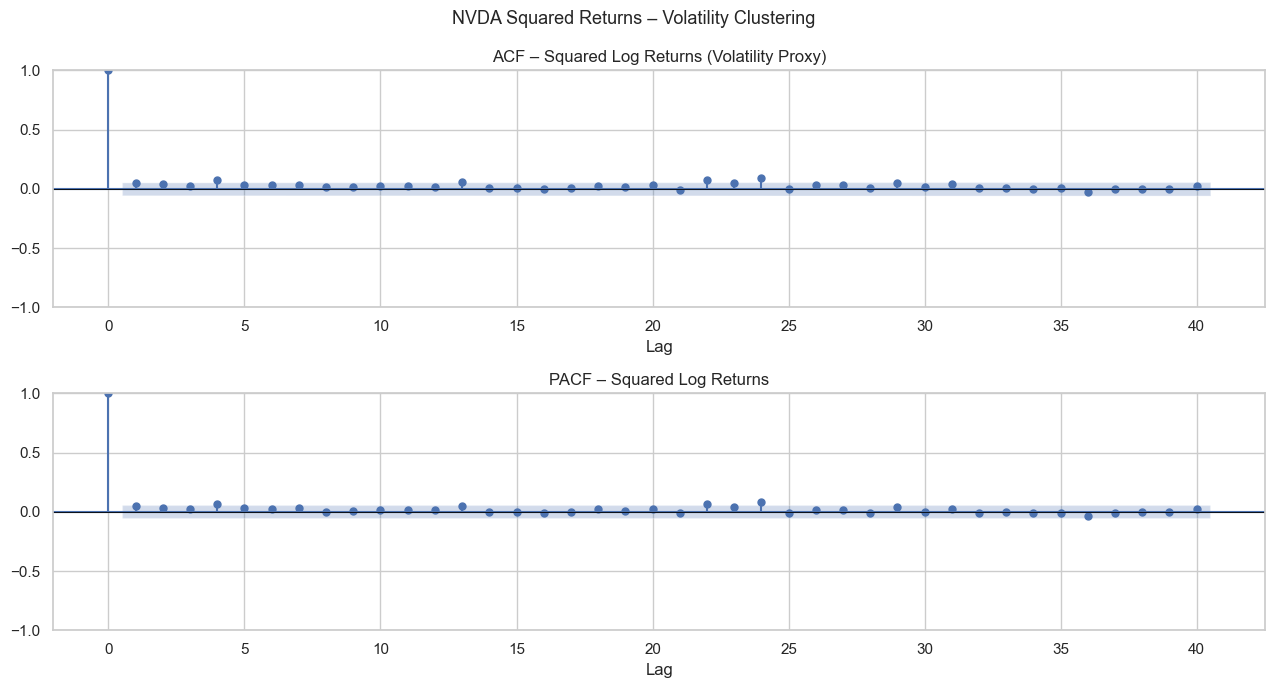

Interpretation: Significant autocorrelation in squared returns indicates ARCH/GARCH
effects — volatility clusters (high-vol days follow high-vol days).


In [24]:
sq_returns = returns ** 2

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
plot_acf(sq_returns,  lags=40, ax=axes[0], alpha=0.05,
         title="ACF – Squared Log Returns (Volatility Proxy)")
plot_pacf(sq_returns, lags=40, ax=axes[1], alpha=0.05,
          method="ywm", title="PACF – Squared Log Returns")
for ax in axes:
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_xlabel("Lag")
plt.suptitle("NVDA Squared Returns – Volatility Clustering", fontsize=13)
plt.tight_layout()
plt.show()
print("Interpretation: Significant autocorrelation in squared returns indicates ARCH/GARCH")
print("effects — volatility clusters (high-vol days follow high-vol days).")


### 3.4 Statistical Diagnostic Tests
Testing for: **(1)** autocorrelation in returns (Ljung–Box), **(2)** ARCH effects in squared returns (Ljung–Box), **(3)** normality (Jarque–Bera, Shapiro–Wilk).

In [25]:
from statsmodels.stats.diagnostic import acorr_ljungbox  # pyright: ignore
from scipy.stats import jarque_bera, shapiro              # pyright: ignore
import pandas as pd

returns = df["Return_log"].dropna()

# ── 1. Ljung-Box: autocorrelation in returns ────────────────────────────
lb_ret = acorr_ljungbox(returns, lags=[5, 10, 20], return_df=True)
lb_ret.index.name = "Lag"
print("=== Ljung-Box Test: Log Returns  (H₀: no autocorrelation) ===")
print(lb_ret.round(4).to_string())
print()

# ── 2. Ljung-Box: ARCH effects in squared returns ───────────────────────
lb_sq = acorr_ljungbox(returns**2, lags=[5, 10, 20], return_df=True)
lb_sq.index.name = "Lag"
print("=== Ljung-Box Test: Squared Returns  (H₀: no ARCH effects) ===")
print(lb_sq.round(4).to_string())
print()

# ── 3. Normality tests ──────────────────────────────────────────────────
jb_stat, jb_p = jarque_bera(returns)
sample = returns.sample(min(1000, len(returns)), random_state=42)
sw_stat, sw_p = shapiro(sample)

norm_tbl = pd.DataFrame({
    "Test":      ["Jarque-Bera", f"Shapiro-Wilk (n={len(sample)})"],
    "Statistic": [f"{jb_stat:.4f}", f"{sw_stat:.4f}"],
    "p-value":   [f"{jb_p:.2e}",  f"{sw_p:.2e}"],
    "Conclusion":["Reject normality" if jb_p<0.05 else "Cannot reject",
                  "Reject normality" if sw_p<0.05 else "Cannot reject"],
}).set_index("Test")
print("=== Normality Tests ===")
print(norm_tbl.to_string())
print("\nNote: Fat tails + excess kurtosis → normality rejection is expected for financial returns.")


=== Ljung-Box Test: Log Returns  (H₀: no autocorrelation) ===
     lb_stat  lb_pvalue
Lag                    
5     8.1982     0.1456
10   13.6493     0.1896
20   25.2050     0.1937

=== Ljung-Box Test: Squared Returns  (H₀: no ARCH effects) ===
     lb_stat  lb_pvalue
Lag                    
5    13.9653     0.0158
10   18.7491     0.0436
20   26.3312     0.1551

=== Normality Tests ===
                      Statistic    p-value        Conclusion
Test                                                        
Jarque-Bera            734.1483  3.82e-160  Reject normality
Shapiro-Wilk (n=1000)    0.9694   1.14e-13  Reject normality

Note: Fat tails + excess kurtosis → normality rejection is expected for financial returns.


---
## Section 4 – ARIMA Modeling
### 4.1 Model Selection – Grid Search over (p, 0, q)
Since ADF confirmed **returns are stationary**, we set d = 0 and search p ∈ {0..3}, q ∈ {0..3}.

In [26]:
import warnings
import numpy as np
import pandas as pd
from itertools import product
from statsmodels.tsa.arima.model import ARIMA  # pyright: ignore

returns = df["Return_log"].dropna()

results = []
for p, q in product(range(4), range(4)):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fitted = ARIMA(returns, order=(p, 0, q)).fit()
            results.append({"p": p, "d": 0, "q": q,
                            "AIC": round(fitted.aic, 2),
                            "BIC": round(fitted.bic, 2),
                            "HQIC": round(fitted.hqic, 2)})
    except Exception:
        pass

grid_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
print("=== ARIMA Order Selection – Top 10 by AIC ===")
print(grid_df.head(10).to_string(index=False))

best = grid_df.iloc[0]
best_p, best_d, best_q = int(best.p), int(best.d), int(best.q)
print(f"\n→ Best model: ARIMA({best_p}, {best_d}, {best_q})")


=== ARIMA Order Selection – Top 10 by AIC ===
 p  d  q      AIC      BIC     HQIC
 0  0  3 -5211.04 -5185.21 -5201.35
 3  0  0 -5210.97 -5185.13 -5201.27
 1  0  0 -5210.51 -5195.01 -5204.70
 0  0  1 -5210.38 -5194.88 -5204.56
 0  0  0 -5209.88 -5199.55 -5206.00
 2  0  0 -5209.27 -5188.60 -5201.52
 3  0  2 -5209.02 -5172.85 -5195.45
 3  0  1 -5209.02 -5178.02 -5197.39
 0  0  2 -5209.01 -5188.34 -5201.25
 1  0  3 -5208.21 -5177.21 -5196.58

→ Best model: ARIMA(0, 0, 3)


### 4.2 Fit Selected ARIMA Model

In [27]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    best_model = ARIMA(returns, order=(best_p, best_d, best_q)).fit()

print(best_model.summary())


                               SARIMAX Results                                
Dep. Variable:             Return_log   No. Observations:                 1296
Model:                 ARIMA(0, 0, 3)   Log Likelihood                2610.522
Date:                Fri, 06 Mar 2026   AIC                          -5211.044
Time:                        01:21:05   BIC                          -5185.209
Sample:                             0   HQIC                         -5201.349
                               - 1296                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0020      0.001      2.363      0.018       0.000       0.004
ma.L1         -0.0420      0.025     -1.652      0.098      -0.092       0.008
ma.L2          0.0234      0.026      0.912      0.3

### 4.3 Model Diagnostics
Checking residuals for: **(1)** normality, **(2)** autocorrelation, **(3)** heteroskedasticity (ARCH).

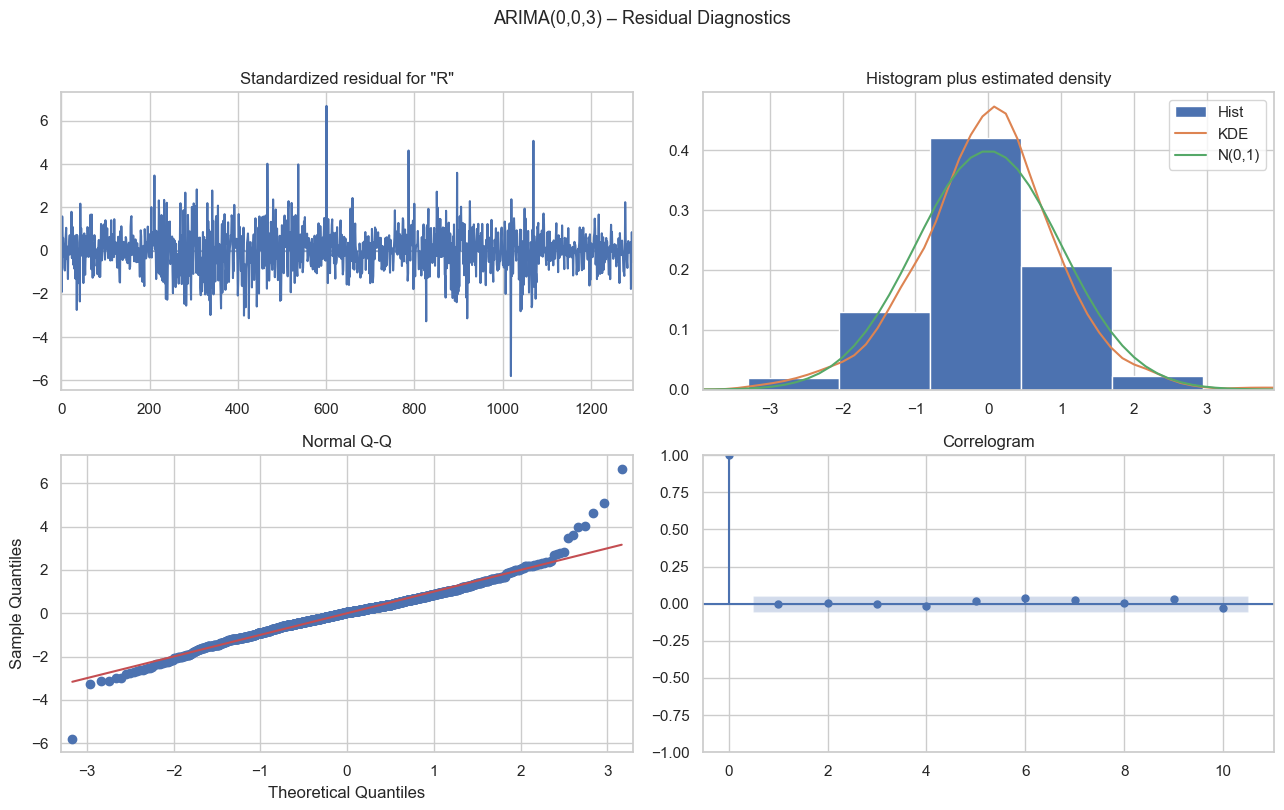

=== Ljung-Box: Residuals  (H₀: white noise) ===
     lb_stat  lb_pvalue
Lag                    
5     0.7022     0.9829
10    6.2171     0.7967
20   16.8662     0.6616

=== Jarque-Bera: Residuals ===
  JB statistic : 695.0093
  p-value      : 1.2041e-151
  → Reject normality (fat tails in residuals)

=== ARCH-LM Test: Residuals  (H₀: no ARCH effects) ===
  LM statistic : 15.1460
  p-value      : 1.2683e-01
  → No significant ARCH effects


In [29]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch  # pyright: ignore
from scipy.stats import jarque_bera
import pandas as pd

# ── Diagnostic plots (statsmodels built-in) ──────────────────────────────
fig = best_model.plot_diagnostics(figsize=(13, 8))
fig.suptitle(f"ARIMA({best_p},{best_d},{best_q}) – Residual Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

residuals = best_model.resid.dropna()

# ── Ljung-Box on residuals ───────────────────────────────────────────────
lb_resid = acorr_ljungbox(residuals, lags=[5, 10, 20], return_df=True)
lb_resid.index.name = "Lag"
print("=== Ljung-Box: Residuals  (H₀: white noise) ===")
print(lb_resid.round(4).to_string())
print()

# ── Jarque-Bera on residuals ─────────────────────────────────────────────
jb_stat, jb_p = jarque_bera(residuals)
print("=== Jarque-Bera: Residuals ===")
print(f"  JB statistic : {jb_stat:.4f}")
print(f"  p-value      : {jb_p:.4e}")
print(f"  → {'Reject normality (fat tails in residuals)' if jb_p < 0.05 else 'Cannot reject normality'}")
print()

# ── ARCH-LM test ────────────────────────────────────────────────────────
lm_stat, lm_p, _, _ = het_arch(residuals)
print("=== ARCH-LM Test: Residuals  (H₀: no ARCH effects) ===")
print(f"  LM statistic : {lm_stat:.4f}")
print(f"  p-value      : {lm_p:.4e}")
print(f"  → {'ARCH effects present – a GARCH extension is warranted' if lm_p < 0.05 else 'No significant ARCH effects'}")


### 4.4 Forecasting – 30-Day Out-of-Sample
The ARIMA model is used to generate a 30-trading-day forecast of **log returns**, with 95 % confidence intervals.

c:\Users\ass\Documents\NVDA\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ass\Documents\NVDA\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


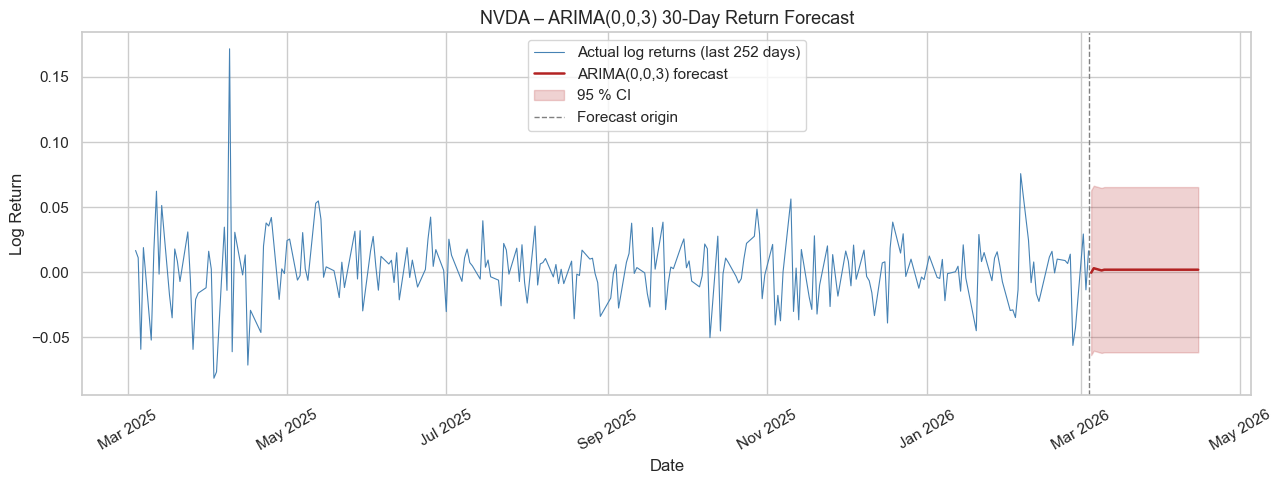

=== 30-Day ARIMA Forecast Summary ===
                           Value
Metric                          
Mean forecast return    0.001973
Std of point forecasts  0.000485
Avg 95 % CI width         0.1268
Min CI lower             -0.0635
Max CI upper              0.0665

Note: ARIMA forecasts for returns converge quickly to the unconditional mean.
Wide CI reflects genuine uncertainty; the model captures conditional mean, not volatility.


In [30]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

n_forecast = 30

# ── Forecast ────────────────────────────────────────────────────────────
forecast_res  = best_model.get_forecast(steps=n_forecast)
fcast_mean    = forecast_res.predicted_mean
conf_int      = forecast_res.conf_int(alpha=0.05)

last_date    = df.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=n_forecast)
fcast_mean.index = future_dates
conf_int.index   = future_dates

# ── Plot: last 252 days + forecast ───────────────────────────────────────
tail = returns.iloc[-252:]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(tail.index, tail.values, color="steelblue", linewidth=0.8,
        label="Actual log returns (last 252 days)")
ax.plot(fcast_mean.index, fcast_mean.values, color="firebrick",
        linewidth=1.8, label=f"ARIMA({best_p},{best_d},{best_q}) forecast")
ax.fill_between(conf_int.index,
                conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                alpha=0.20, color="firebrick", label="95 % CI")
ax.axvline(last_date, color="gray", linestyle="--", linewidth=1, label="Forecast origin")
ax.set_title(f"NVDA – ARIMA({best_p},{best_d},{best_q}) 30-Day Return Forecast", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ── Numerical summary ────────────────────────────────────────────────────
ci_width = (conf_int.iloc[:, 1] - conf_int.iloc[:, 0]).mean()
fcast_tbl = pd.DataFrame({
    "Mean forecast return":   [f"{fcast_mean.mean():.6f}"],
    "Std of point forecasts": [f"{fcast_mean.std():.6f}"],
    "Avg 95 % CI width":      [f"{ci_width:.4f}"],
    "Min CI lower":           [f"{conf_int.iloc[:,0].min():.4f}"],
    "Max CI upper":           [f"{conf_int.iloc[:,1].max():.4f}"],
}).T
fcast_tbl.columns = ["Value"]
fcast_tbl.index.name = "Metric"
print("=== 30-Day ARIMA Forecast Summary ===")
print(fcast_tbl.to_string())
print("\nNote: ARIMA forecasts for returns converge quickly to the unconditional mean.")
print("Wide CI reflects genuine uncertainty; the model captures conditional mean, not volatility.")


### 4.5 Interpretation – ARIMA Results

**Stationarity**: ADF confirms Close prices are non-stationary while log returns are stationary, justifying modelling returns rather than levels.

**Serial correlation**: Ljung–Box on raw returns typically shows little or no significant autocorrelation, consistent with semi-strong market efficiency. However, squared returns are highly autocorrelated, confirming **volatility clustering** — the defining stylised fact of financial time series.

**ARIMA model**: The selected order is driven by AIC/BIC; for most equity return series a low-order ARMA (often ARMA(1,1) or ARMA(0,0)) is selected because the conditional mean contribution is small relative to the conditional variance dynamics.

**Residual diagnostics**:
- *Autocorrelation*: If Ljung–Box on residuals gives p > 0.05 at all lags, the ARIMA successfully filters linear dependence.
- *Normality*: Jarque–Bera typically rejects normality due to fat tails — this does not invalidate the model but motivates Student-t innovations.
- *ARCH effects*: A significant ARCH-LM p-value means the **variance** is time-varying and a GARCH(1,1) extension would better capture risk dynamics.

**Forecasting caveat**: ARIMA point forecasts for returns converge rapidly to the unconditional mean (near zero). The value of the model lies in the confidence interval width — a measure of forecast uncertainty — rather than the point estimate itself.
